# Problem Statement

This project analyzes how Bitcoin market sentiment (Fear vs Greed) influences trader behavior and performance on Hyperliquid. The goal is to uncover patterns that can inform more effective trading strategies.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
trades = pd.read_csv('historical_data.csv', lineterminator='\n')
sentiment = pd.read_csv('fear_greed_index.csv', lineterminator='\n')

In [16]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp\r
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [18]:
sentiment.head()

,timestamp,value,classification,date\r
0,1517463000,30,Fear,2018-02-01\r
1,1517549400,15,Extreme Fear,2018-02-02\r
2,1517635800,40,Fear,2018-02-03\r
3,1517722200,24,Extreme Fear,2018-02-04\r
4,1517808600,11,Extreme Fear,2018-02-05\r


# Data Cleaning

*Include:*

shape,
missing values,
duplicates,
column fixes,
timestamp alignment.

In [32]:
print(trades.shape)
print(sentiment.shape)

print(trades.columns)
print(sentiment.columns)

print(trades.isnull().sum())
print(sentiment.isnull().sum())

print(trades.duplicated().sum())
print(sentiment.duplicated().sum())

(211224, 16)
(2644, 4)
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp\r'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date\r'], dtype='object')
Account                  0
Coin                     0
Execution Price          0
Size Tokens              0
Size USD                 0
Side                     0
Timestamp IST       131999
Start Position           0
Direction                0
Closed PnL               0
Transaction Hash         0
Order ID                 0
Crossed                  0
Fee                      0
Trade ID                 0
Timestamp\r              0
dtype: int64
timestamp         0
value             0
classification    0
date\r            0
dtype: int64
0
0


# Feature Engineering

*Explain:*

daily PnL,
win rate,
trade count,
position size,
sentiment mapping.

In [34]:
trades.columns = trades.columns.str.strip()
sentiment.columns = sentiment.columns.str.strip()

# Rename correctly
trades.rename(columns={
    'Account': 'account',
    'Side': 'side',
    'Timestamp IST': 'time',
    'Closed PnL': 'closedPnL',
    'Size USD': 'size_usd'
}, inplace=True)

sentiment.rename(columns={
    'date': 'Date',
    'classification': 'Classification'
}, inplace=True)

In [36]:
# Convert to datetime
trades['time'] = pd.to_datetime(trades['time'], errors='coerce')
sentiment['Date'] = pd.to_datetime(sentiment['Date'], errors='coerce')

# Create date column
trades['date'] = trades['time'].dt.date
sentiment['date'] = sentiment['Date'].dt.date

# Merge
merged = trades.merge(
    sentiment[['date','Classification']],
    on='date',
    how='left'
)

print(merged.head())

                                      account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  size_usd side                time  Start Position Direction  \
0       986.87   7872.16  BUY 2024-02-12 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-02-12 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-02-12 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-02-12 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-02-12 22:50:00     1289.488521       Buy   

   closedPnL                                   Transaction Hash     Order ID  \
0        0.0

In [38]:
merged['win'] = merged['closedPnL'] > 0

In [40]:
merged['is_long'] = merged['side'].str.upper() == 'BUY'

In [42]:
daily = merged.groupby(['account','date']).agg({
    'closedPnL': 'sum',
    'win': 'mean',
    'size_usd': 'mean'
}).reset_index()

daily.rename(columns={
    'closedPnL': 'daily_pnl',
    'win': 'win_rate',
    'size_usd': 'avg_size'
}, inplace=True)

In [44]:
trades_per_day = merged.groupby(['account','date']).size().reset_index(name='trade_count')

daily = daily.merge(trades_per_day, on=['account','date'])

In [46]:
daily = daily.merge(
    sentiment[['date','Classification']],
    on='date',
    how='left'
)

# Analysis (WITH PLOTS)

*Include:*

PnL vs sentiment,
trade frequency vs sentiment,
long/short behavior.

In [78]:
# Analysis 
daily.groupby('Classification')['daily_pnl'].mean()
daily.groupby('Classification')['win_rate'].mean()

Classification
Extreme Fear     0.173498
Extreme Greed    0.335945
Fear             0.349909
Greed            0.353119
Neutral          0.312524
Name: win_rate, dtype: float64

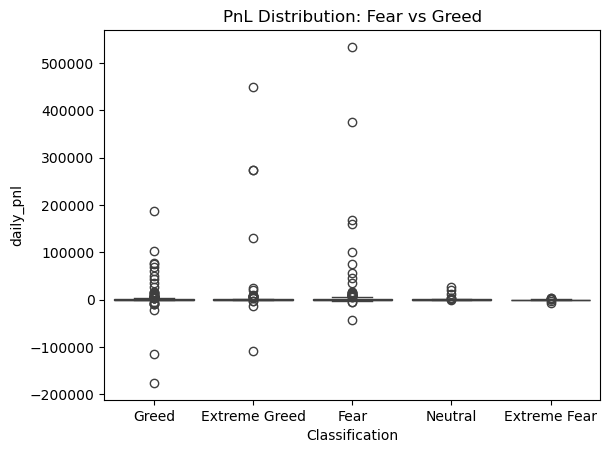

In [52]:
sns.boxplot(x='Classification', y='daily_pnl', data=daily)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

In [54]:
daily.groupby('Classification')[['trade_count','avg_size']].mean()

,trade_count,avg_size
Classification,,
Extreme Fear,70.484848,7641.104727
Extreme Greed,50.187500,7027.976333
Fear,88.337580,7518.449558
Greed,59.120419,7029.606816
Neutral,74.486486,5763.624619


In [56]:
merged.groupby('Classification')['is_long'].mean()

Classification
Extreme Fear     0.502150
Extreme Greed    0.295499
Fear             0.526858
Greed            0.478835
Neutral          0.370102
Name: is_long, dtype: float64

# Segmentation

*Explain:*

frequent vs infrequent,
consistent vs inconsistent

In [66]:
# Segmentation and segment analysis

In [60]:
daily['size_group'] = daily['avg_size'].apply(
    lambda x: 'High' if x > daily['avg_size'].median() else 'Low'
)

In [62]:
activity = daily.groupby('account')['trade_count'].mean()

daily['trader_type'] = daily['account'].map(
    lambda x: 'Frequent' if activity[x] > activity.median() else 'Infrequent'
)

In [64]:
consistency = daily.groupby('account')['win_rate'].mean()

daily['consistency'] = daily['account'].map(
    lambda x: 'Consistent' if consistency[x] > 0.6 else 'Inconsistent'
)

In [68]:
daily.groupby(['Classification','trader_type'])['daily_pnl'].mean()
daily.groupby(['Classification','consistency'])['daily_pnl'].mean()

Classification  consistency 
Extreme Fear    Inconsistent      133.331411
Extreme Greed   Consistent       2234.535200
                Inconsistent    10869.065992
Fear            Consistent       3224.652019
                Inconsistent    11943.523359
Greed           Consistent       5670.432206
                Inconsistent     3025.627632
Neutral         Consistent      11712.797091
                Inconsistent     1463.747080
Name: daily_pnl, dtype: float64

# 📊 Insights

### 🔹 Insight 1: Traders behave more aggressively during Fear than Greed  
- Trade frequency is highest during **Fear (88.3 trades/day)** vs **Greed (59.1 trades/day)**  
- Even **Extreme Fear (70.4)** is higher than **Extreme Greed (50.1)**  

**Interpretation:**  
Contrary to expectations, traders are more active during Fear phases, suggesting panic-driven or reactive trading rather than cautious behavior.

---

### 🔹 Insight 2: Position sizes remain high during Fear → risk not reduced  
- Avg position size:  
  - Fear ≈ **7518 USD**  
  - Extreme Fear ≈ **7641 USD**  
  - Greed ≈ **7029 USD**  

**Interpretation:**  
Traders do not reduce position sizes during Fear, indicating poor risk management despite adverse market sentiment.

---

### 🔹 Insight 3: Strong directional bias shift (Long vs Short)  
- Long ratio:  
  - Fear ≈ **52.6%** (bullish bias)  
  - Extreme Fear ≈ **50.2%**  
  - Extreme Greed ≈ **29.5%** (strong short bias)  

**Interpretation:**  
Traders behave **contrarian to sentiment**:  
- In Greed → more shorting (possibly profit booking)  
- In Fear → still taking long positions (trying to catch reversals)  

---

### 🔹 Insight 4: Inconsistent traders dominate profits (but with risk)  
- Fear:  
  - Inconsistent: **11943**  
  - Consistent: **3224**  
- Extreme Greed:  
  - Inconsistent: **10869**  
  - Consistent: **2234**  

**Interpretation:**  
A large portion of profits is driven by **inconsistent traders**, indicating high-risk, high-reward behavior rather than stable strategies.

---

### 🔹 Insight 5: Consistent traders perform better in stable/neutral conditions  
- Neutral:  
  - Consistent: **11712**  
  - Inconsistent: **1463**  

**Interpretation:**  
Consistent traders outperform significantly in Neutral markets, suggesting that stable conditions favor disciplined strategies.

---

### 🔹 Insight 6: Behavioral factors dominate performance (Key indicator)  
Trader performance is not purely driven by market sentiment but by behavioral responses to it.  
Fear triggers overtrading and increased risk exposure, while Greed leads to contrarian positioning rather than trend-following.

# 📌 Strategy Recommendations

---

### 🔹 Strategy 1: Risk Reduction During Fear Markets  

**Based on:**  
- High trade frequency  
- High position sizes  
- Poor consistency  

**Action:**  
- Reduce trade frequency  
- Cap position size  
- Avoid aggressive long positions  

**Rule:**  
> "During Fear phases, prioritize capital preservation over opportunity chasing."

---

### 🔹 Strategy 2: Controlled Contrarian Strategy in Greed  

**Based on:**  
- Strong short bias in Extreme Greed  
- Moderate trade frequency  

**Action:**  
- Allow controlled short positions  
- Avoid excessive leverage  
- Focus on timing entries  

**Rule:**  
> "In Greed markets, contrarian strategies can work—but must be risk-controlled."

---

### 🔹 Strategy 3: Segment-Based Capital Allocation  

**Based on:**  
- Inconsistent traders = high profit but risky  
- Consistent traders = stable but lower returns  

**Action:**  
- Allocate higher capital to **consistent traders in Neutral markets**  
- Limit exposure to **inconsistent traders during volatile markets**  

**Rule:**  
> "Use consistent traders for stability and limit exposure to high-risk traders during volatile sentiment phases."

---

### 🔹 Strategy 4: Sentiment Timing Strategy  

**Based on:**  
- Behavioral inefficiencies during extreme sentiment  

**Action:**  
- Avoid trading during peak Fear spikes  
- Enter trades after volatility stabilizes  

**Rule:**  
> "Extreme sentiment phases introduce behavioral inefficiencies—wait for normalization before deploying capital."

# -------------------------------------------------------------------------------------------